<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/18_monetary_transmission_var.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# Set seed for reproducible econometric dynamics
np.random.seed(42)
QUARTERS = 36

# Quarterly dates from 2016-Q1 to 2024-Q4
timeline = pd.date_range(start="2016-01-01", periods=QUARTERS, freq="QE")

# Baseline variables
repo_rate = np.zeros(QUARTERS)
walr = np.zeros(QUARTERS)
credit_growth = np.zeros(QUARTERS)
inflation = np.zeros(QUARTERS)

# Initial baseline equilibrium
repo_rate[0] = 6.50
walr[0] = 9.80
credit_growth[0] = 11.20
inflation[0] = 5.20

# Simulate structural transmission with lagged feedback
for t in range(1, QUARTERS):
    # Repo Rate follows Taylor-rule-like policy response to lagged inflation
    repo_shock = np.random.normal(0, 0.20)
    repo_rate[t] = max(
        4.0,
        0.75 * repo_rate[t - 1]
        + 0.25 * (4.0 + 0.5 * (inflation[t - 1] - 4.0))
        + repo_shock,
    )

    # Lending rate (WALR) adjusts to policy rate with sticky pass-through
    walr_shock = np.random.normal(0, 0.15)
    walr[t] = 0.60 * walr[t - 1] + 0.40 * (repo_rate[t] + 3.20) + walr_shock

    # Credit growth slows when lending rates rise
    credit_shock = np.random.normal(0, 0.60)
    credit_growth[t] = (
        0.70 * credit_growth[t - 1] - 0.80 * (walr[t] - walr[t - 1]) + credit_shock + 3.5
    )

    # Inflation moderates as credit slows with delayed impact
    inf_shock = np.random.normal(0, 0.45)
    inflation[t] = (
        0.65 * inflation[t - 1]
        + 0.15 * (credit_growth[t - 1] - 10.0)
        - 0.30 * (repo_rate[t - 1] - 5.5)
        + inf_shock
        + 1.8
    )

df_trans = pd.DataFrame(
    {
        "Quarter": timeline,
        "Repo_Rate_%": np.round(repo_rate, 2),
        "WALR_%": np.round(walr, 2),
        "Credit_Growth_%": np.round(credit_growth, 2),
        "CPI_Inflation_%": np.round(inflation, 2),
    }
).set_index("Quarter")

df_trans.to_csv("monetary_transmission_data.csv")
print("Macro-financial transmission time-series created (36 quarters).")
print(df_trans.head())

Macro-financial transmission time-series created (36 quarters).
            Repo_Rate_%  WALR_%  Credit_Growth_%  CPI_Inflation_%
Quarter                                                          
2016-03-31         6.50    9.80            11.20             5.20
2016-06-30         6.12    9.59            11.90             5.75
2016-09-30         5.76    9.30            13.00             5.98
2016-12-31         5.48    9.13            12.46             5.85
2017-03-31         5.39    8.63            11.59             5.72


In [2]:
df_trans = pd.read_csv("monetary_transmission_data.csv", index_col="Quarter")


def check_stationarity(df):
    results = {}
    for col in df.columns:
        res = adfuller(df[col].dropna())
        results[col] = {"ADF_Stat": round(res[0], 3), "p_value": round(res[1], 4)}
    return pd.DataFrame(results).T


print("--- Raw Series ADF Unit Root Test (p < 0.05 indicates stationarity) ---")
print(check_stationarity(df_trans))

# Apply first differencing to achieve stationarity across variables
df_diff = df_trans.diff().dropna()

print("\n--- Differenced Series (Δ) ADF Test ---")
print(check_stationarity(df_diff))

--- Raw Series ADF Unit Root Test (p < 0.05 indicates stationarity) ---
                 ADF_Stat  p_value
Repo_Rate_%        -2.739   0.0675
WALR_%             -3.544   0.0069
Credit_Growth_%    -4.492   0.0002
CPI_Inflation_%    -3.490   0.0082

--- Differenced Series (Δ) ADF Test ---
                 ADF_Stat  p_value
Repo_Rate_%        -4.890   0.0000
WALR_%             -5.571   0.0000
Credit_Growth_%    -2.796   0.0588
CPI_Inflation_%    -2.234   0.1941


In [3]:
# 1. Initialize VAR model on differenced series
model = VAR(df_diff)

# 2. Select optimal lag order (up to 4 quarters / 1 year)
lag_order_selection = model.select_order(maxlags=4)
print("--- VAR Lag Order Selection Criteria ---")
print(lag_order_selection.summary())

# Select lag order 1 based on parsimonious criteria (AIC/BIC)
optimal_lag = 1
var_results = model.fit(optimal_lag)

print(f"\n--- Fitted VAR({optimal_lag}) Model Summary ---")
print(f"Degrees of freedom: {var_results.df_resid}")
print(f"Log-Likelihood:     {var_results.llf:.2f}")
print(f"AIC:                {var_results.aic:.3f}")

--- VAR Lag Order Selection Criteria ---
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -8.705     -8.520*  0.0001658*     -8.645*
1      -8.421      -7.496   0.0002226      -8.120
2      -8.198      -6.533   0.0002947      -7.655
3      -8.658      -6.253   0.0002165      -7.874
4     -8.824*      -5.679   0.0002529      -7.799
-------------------------------------------------

--- Fitted VAR(1) Model Summary ---
Degrees of freedom: 29
Log-Likelihood:     -32.92
AIC:                -8.239


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-DEC will be used.
  self._init_dates(dates, freq)


In [4]:
print("--- Granger Causality Diagnostics ---")
for target in ["WALR_%", "Credit_Growth_%", "CPI_Inflation_%"]:
    test_result = var_results.test_causality(
        causing=["Repo_Rate_%"], caused=target, kind="f"
    )
    print(
        f"Repo Rate Granger-causes {target:<18} | F-stat: {test_result.test_statistic:.3f} | p-value: {test_result.pvalue:.4f}"
    )

--- Granger Causality Diagnostics ---
Repo Rate Granger-causes WALR_%             | F-stat: 13.774 | p-value: 0.0003
Repo Rate Granger-causes Credit_Growth_%    | F-stat: 4.382 | p-value: 0.0385
Repo Rate Granger-causes CPI_Inflation_%    | F-stat: 0.011 | p-value: 0.9174


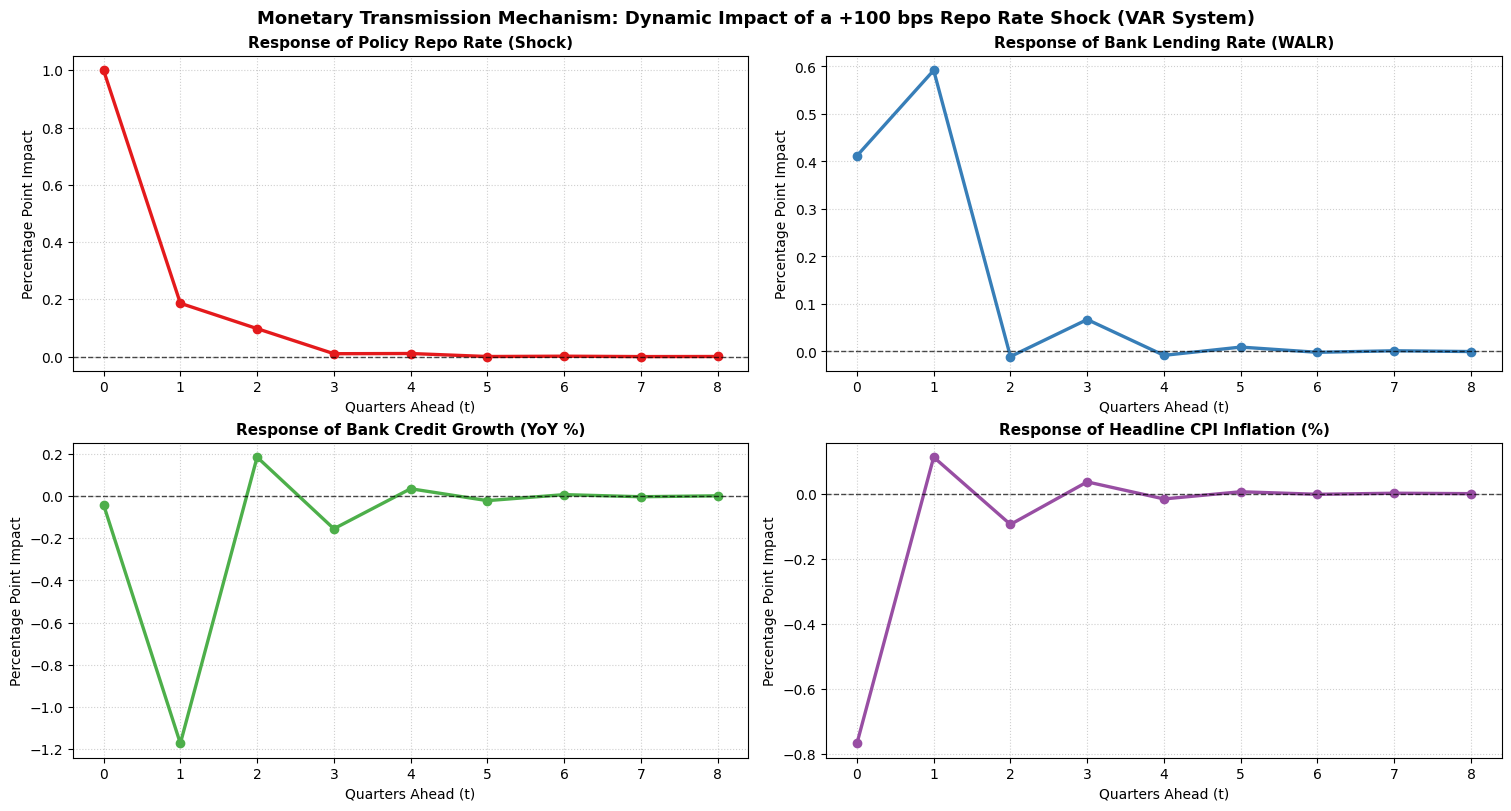

In [5]:
# Compute Orthogonalized Impulse Response Functions (IRF) for 8 quarters ahead
HORIZON = 8
irf = var_results.irf(HORIZON)

# Extract impulse responses originating specifically from a Repo Rate shock
repo_idx = df_diff.columns.get_loc("Repo_Rate_%")
irf_matrix = irf.orth_irfs  # Shape: (HORIZON + 1, num_vars, num_vars)
cum_effects = irf.cum_effects

# Scale unit standard-deviation shock to a normalized 1.00% (100 bps) shock
shock_scale = 1.0 / irf_matrix[0, repo_idx, repo_idx]

periods = np.arange(HORIZON + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 8), layout="constrained")
var_names = [
    (
        "Repo_Rate_%",
        "Policy Repo Rate (Shock)",
        "#e41a1c",
        axes[0, 0],
    ),
    (
        "WALR_%",
        "Bank Lending Rate (WALR)",
        "#377eb8",
        axes[0, 1],
    ),
    (
        "Credit_Growth_%",
        "Bank Credit Growth (YoY %)",
        "#4daf4a",
        axes[1, 0],
    ),
    (
        "CPI_Inflation_%",
        "Headline CPI Inflation (%)",
        "#984ea3",
        axes[1, 1],
    ),
]

for col_name, title, color, ax in var_names:
    col_idx = df_diff.columns.get_loc(col_name)

    # Scaled impulse response trajectory
    response = irf_matrix[:, col_idx, repo_idx] * shock_scale

    # Plot response path
    ax.plot(
        periods,
        response,
        color=color,
        linewidth=2.4,
        marker="o",
        label="Impulse Path",
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)

    ax.set_title(f"Response of {title}", fontsize=11, weight="bold")
    ax.set_xlabel("Quarters Ahead (t)")
    ax.set_ylabel("Percentage Point Impact")
    ax.set_xticks(periods)
    ax.grid(True, linestyle=":", alpha=0.6)

fig.suptitle(
    "Monetary Transmission Mechanism: Dynamic Impact of a +100 bps Repo Rate Shock (VAR System)",
    fontsize=13,
    weight="bold",
)

plt.show()